In [1]:
# STEP 1: Import required libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# STEP 2: Select device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [3]:
# STEP 3: Load and preprocess MNIST dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 897kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.36MB/s]

Training images: 60000
Testing images: 10000


In [4]:
# STEP 4: Create DataLoaders

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


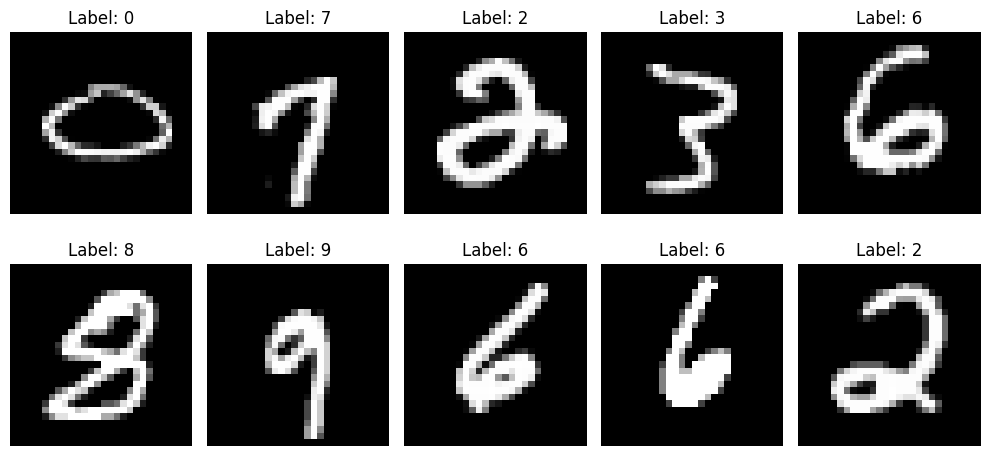

In [5]:
# STEP 5: Display sample MNIST images

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
"""Input
  ↓
Conv2D
  ↓
ReLU
  ↓
Max Pooling
  ↓
Conv2D
  ↓
ReLU
  ↓
Max Pooling
  ↓
Fully Connected
  ↓
10 Classes"""

In [6]:
# STEP 6: Define CNN model

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Max pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected layers
        self.fc1 = nn.Linear(
            32 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        # First convolution
        x = self.conv1(x)

        x = torch.relu(x)

        x = self.pool(x)

        # Second convolution
        x = self.conv2(x)

        x = torch.relu(x)

        x = self.pool(x)

        # Flatten
        x = x.view(
            x.size(0),
            -1
        )

        # Fully connected
        x = torch.relu(self.fc1(x))

        # Output
        x = self.fc2(x)

        return x


model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
# STEP 8: Define loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created!")

Loss function and optimizer created!


In [8]:
# STEP 9: Train the CNN

epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Prediction
        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.1644 Accuracy: 94.97%
Epoch [2/5] Loss: 0.0497 Accuracy: 98.47%
Epoch [3/5] Loss: 0.0343 Accuracy: 98.93%
Epoch [4/5] Loss: 0.0252 Accuracy: 99.21%
Epoch [5/5] Loss: 0.0198 Accuracy: 99.33%


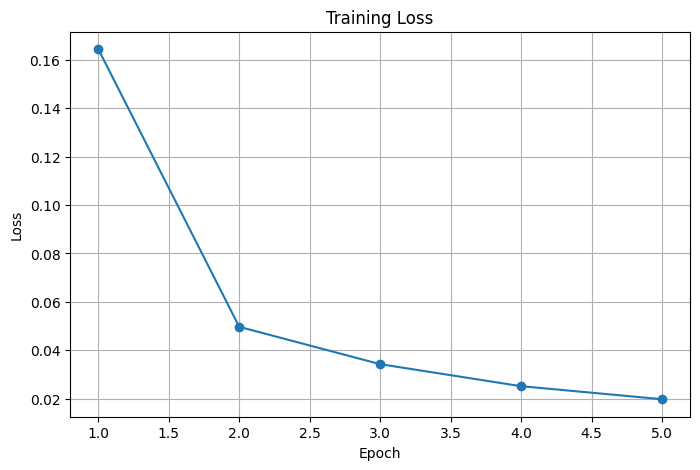

In [9]:
# STEP 10: Plot training loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.show()

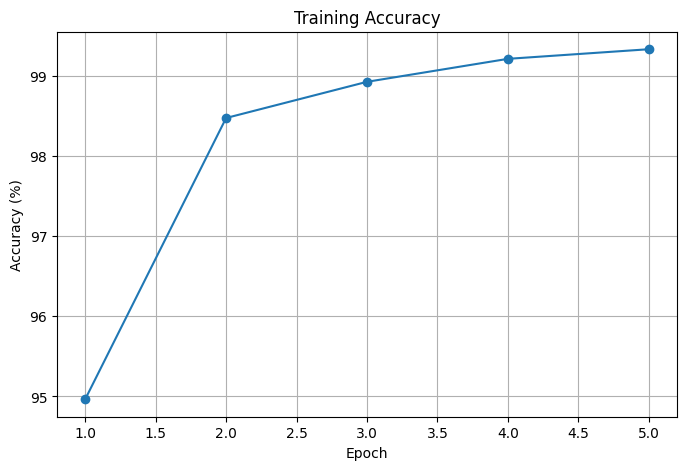

In [10]:
# STEP 11: Plot training accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_accuracies,
    marker="o"
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()

plt.show()

In [11]:
# STEP 12: Evaluate CNN on test dataset

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = (
    100 * correct / total
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 98.65%


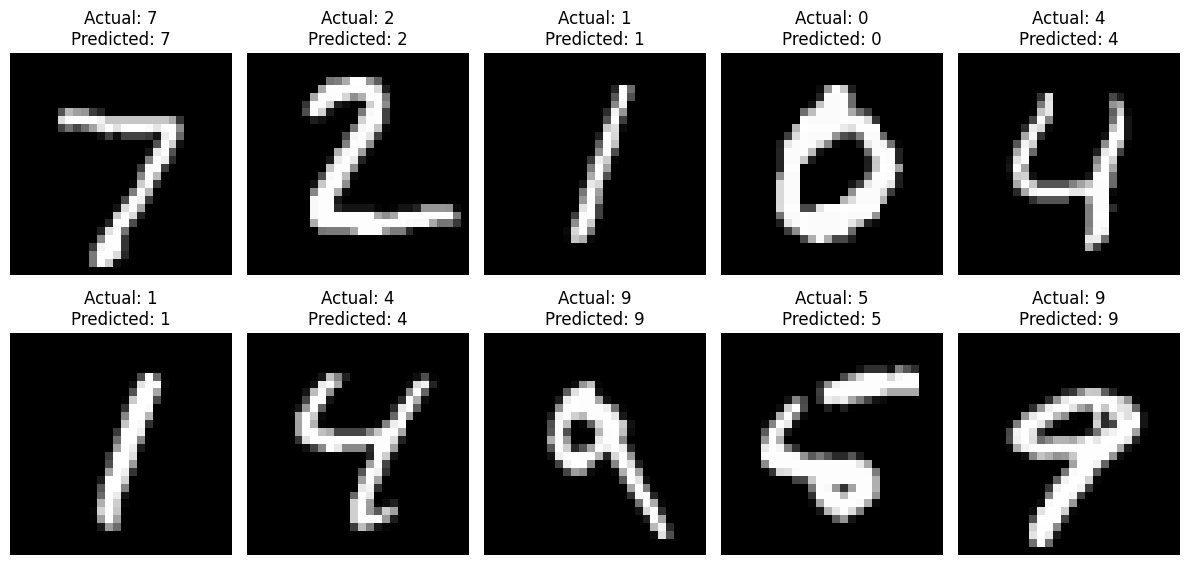

In [12]:
# STEP 13: Display predictions

model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    outputs = model(images_device)

    _, predictions = torch.max(
        outputs,
        1
    )

plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Predicted: {predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# STEP 15: Extract feature maps from first convolution layer

model.eval()

sample_image = images[0].unsqueeze(0).to(device)

with torch.no_grad():

    feature_maps = model.conv1(
        sample_image
    )

    feature_maps = torch.relu(
        feature_maps
    )

print(
    "Feature map shape:",
    feature_maps.shape
)

Feature map shape: torch.Size([1, 16, 28, 28])


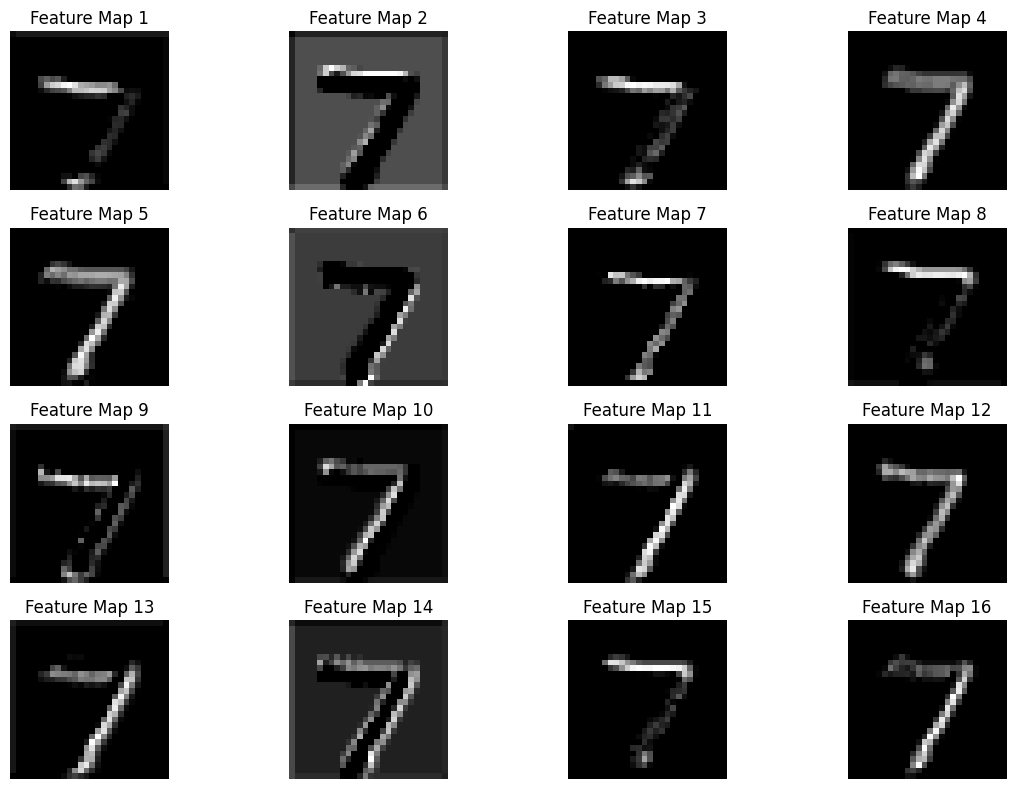

In [14]:
# STEP 16: Visualize CNN feature maps

feature_maps = feature_maps.squeeze(0).cpu()

plt.figure(figsize=(12, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        feature_maps[i],
        cmap="gray"
    )

    plt.title(
        f"Feature Map {i+1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# STEP 19: Prepare image for saliency map

model.eval()

saliency_image = images[0].unsqueeze(0).to(device)

saliency_image.requires_grad_()

print(
    "Image prepared for saliency analysis!"
)

Image prepared for saliency analysis!


In [16]:
# STEP 20: Calculate saliency map

model.zero_grad()

output = model(
    saliency_image
)

predicted_class = output.argmax(
    dim=1
)

score = output[
    0,
    predicted_class
]

score.backward()

saliency = saliency_image.grad.abs()

saliency = saliency.squeeze().cpu()

print(
    "Predicted digit:",
    predicted_class.item()
)

Predicted digit: 7


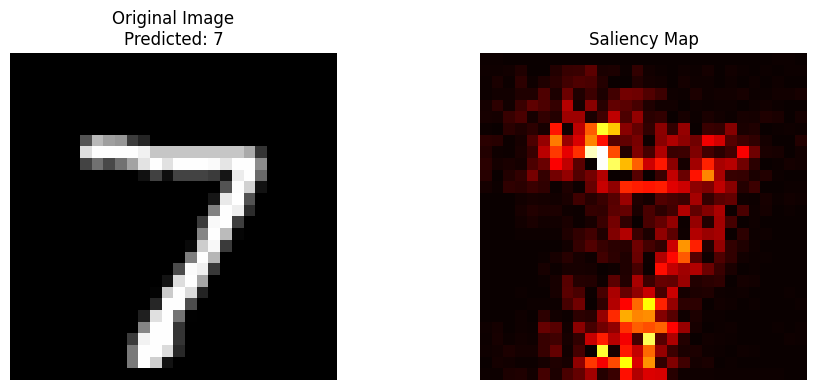

In [17]:
# STEP 21: Display saliency map

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.imshow(
    images[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Original Image\n"
    f"Predicted: {predicted_class.item()}"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    saliency,
    cmap="hot"
)

plt.title("Saliency Map")

plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# STEP 23: Save trained CNN model

torch.save(
    model.state_dict(),
    "/content/mnist_cnn.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [19]:
from sklearn.metrics import classification_report

In [20]:
# STEP 11: Classification Report

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate classification report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=[str(i) for i in range(10)]
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.97      0.99      0.98      1028
           8       0.99      0.97      0.98       974
           9       1.00      0.96      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

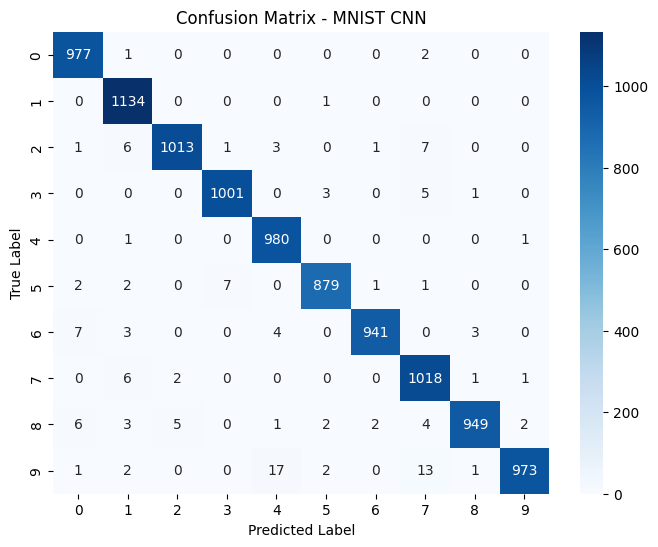

In [22]:
# STEP 12: Confusion Matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MNIST CNN")
plt.show()